# Mood-Aware Book Recommendation system
## Feature Engineering

In the previous cleaning stage, we focused on data quality. Now, we move into **Feature engineering**, where we transform text and metadata into numerical formats that a recommendation engine can understand. 

Our primary goal is to create a "Mood Vector" for every book by analising:
- **Semantic content:** The emotional and descriptive weight of the book's summary. 
- **User-generated data:** Tags that signal specific genres and atmospheres. 
- **Contextual metadata:** Using metrics like popularity and length to refine recommendation ranking.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import ast

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## Dataset Overview
At this stage we load the cleaned dataset produced during preprocessing. 
As seen before, the dataset includes: 
- Book metadata
- Tag lists
- Decriptions
- Genre indicators

These fields will be transformed into strucutred features ready for processing. 

In [2]:
# Load cleaned dataset
df = pd.read_csv('../data/processed/books_cleaned.csv')

# Convert string representations of lists back to actual Python lists
df['authors'] = df['authors'].apply(ast.literal_eval)
df['tags_cleaned'] = df['tags_cleaned'].apply(ast.literal_eval)

print(f"Loaded {len(df)} books")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 5006 books
Columns: ['book_id', 'title', 'description_cleaned', 'description_length', 'description_word_count', 'average_rating', 'num_pages', 'ratings_count', 'publication_year', 'authors', 'tags_cleaned', 'num_tags']


,book_id,title,description_cleaned,description_length,description_word_count,average_rating,num_pages,ratings_count,publication_year,authors,tags_cleaned,num_tags
0,7327624,"The Unschooled Wizard (Sun Wolf and Starhawk, ...",Omnibus book club edition containing the Ladie...,87,14,4.03,600,140,1987.0,[10333],"[fantasy, fiction, might-read, dnf-d, hambly-b...",58
1,34883016,Playmaker: A Venom Series Novella,Secrets. Sometimes keeping them in confidence ...,885,154,3.86,0,5,2017.0,[5807700],"[favorite-authors, may-2017-dr-reads, sports-r...",7
2,3209316,Emma,The funny and heartwarming story of a young la...,633,101,3.99,544,42,2005.0,[1265],"[classics, fiction, romance, jane-austen, hist...",44
3,17320317,The Gingrich Senators: The Roots of Partisan W...,"The Senate of the mid twentieth century, which...",1499,231,4.00,240,10,2013.0,[834674],"[politics, non-fiction]",2
4,9671976,Botham's Book of the Ashes: A Lifetime Love Af...,Sir Ian Botham and the Ashes are as closely in...,1241,228,3.71,272,7,2010.0,[285644],"[cricket, non-fiction-sports, autobiography-bi...",3


## Analyse Tag Distribution
Tags provide valuable signals describing themes, tone, audience and gender overlap. Understanding their distribution helps us decide which tags are suitable for feature creation. 

In [3]:
# Extract all tags across all books
all_tags = []
for tags in df['tags_cleaned']:
    all_tags.extend(tags)

tag_counts = Counter(all_tags)

print(f"Total unique tags: {len(tag_counts)}")
print(f"Total tag instances: {len(all_tags)}")
print(f"\nTop 30 most common tags:")
for tag, count in tag_counts.most_common(30):
    print(f"  {tag}: {count} ({count/len(df)*100:.1f}% of books)")

Total unique tags: 76929
Total tag instances: 230056

Top 30 most common tags:
  fiction: 2458 (49.1% of books)
  romance: 1326 (26.5% of books)
  non-fiction: 1258 (25.1% of books)
  contemporary: 1223 (24.4% of books)
  adult: 1145 (22.9% of books)
  fantasy: 1025 (20.5% of books)
  mystery: 950 (19.0% of books)
  historical-fiction: 860 (17.2% of books)
  young-adult: 835 (16.7% of books)
  history: 729 (14.6% of books)
  children: 666 (13.3% of books)
  thriller: 663 (13.2% of books)
  science-fiction: 604 (12.1% of books)
  adventure: 597 (11.9% of books)
  suspense: 505 (10.1% of books)
  literature: 498 (9.9% of books)
  crime: 495 (9.9% of books)
  paranormal: 489 (9.8% of books)
  humor: 486 (9.7% of books)
  classics: 472 (9.4% of books)
  drama: 438 (8.7% of books)
  family: 437 (8.7% of books)
  biography: 373 (7.5% of books)
  short-stories: 361 (7.2% of books)
  chick-lit: 360 (7.2% of books)
  horror: 343 (6.9% of books)
  literary-fiction: 339 (6.8% of books)
  supernat

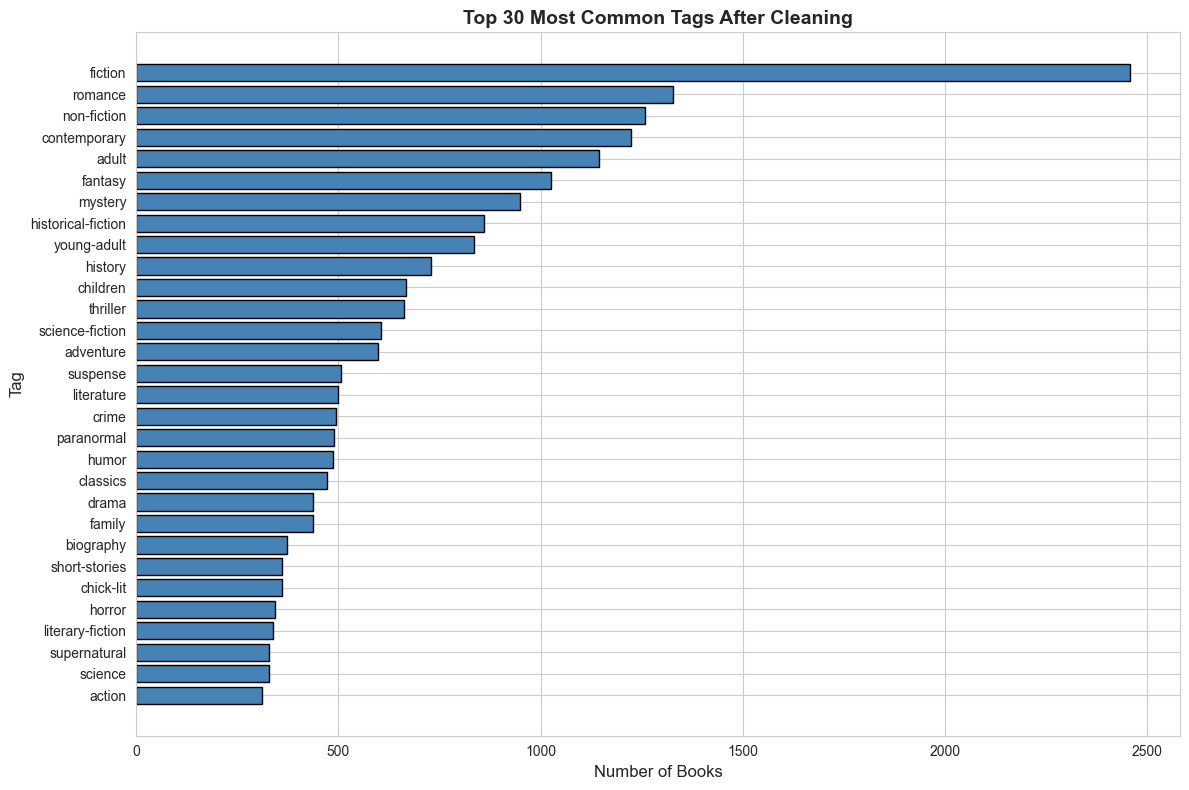

In [4]:
# Visualize top tags
top_tags = tag_counts.most_common(30)
tags, counts = zip(*top_tags)

plt.figure(figsize=(12, 8))
plt.barh(range(len(tags)), counts, color='steelblue', edgecolor='black')
plt.yticks(range(len(tags)), tags)
plt.xlabel('Number of Books', fontsize=12)
plt.ylabel('Tag', fontsize=12)
plt.title('Top 30 Most Common Tags After Cleaning', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Define mood categories
Mood-based signals capture the emotional tone of books, which is useful for clustering similar books and reader preference modeling. 

Here, we manually group common tags into interpretable mood categories. 

In [5]:
# Define mood categories based on observed tags
MOOD_TAGS = {
    'dark': ['dark', 'horror', 'thriller', 'suspense', 'crime', 'mystery', 'noir', 'disturbing', 'creepy'],
    'light': ['humor', 'funny', 'humorous', 'comedy', 'lighthearted', 'feel-good', 'uplifting'],
    'emotional': ['drama', 'family', 'love', 'romantic', 'heartbreaking', 'moving', 'touching', 'sad'],
    'adventurous': ['adventure', 'action', 'epic', 'quest', 'journey', 'exploration'],
    'intellectual': ['philosophy', 'science', 'history', 'biography', 'literary-fiction', 'thought-provoking', 'academic'],
    'escapist': ['fantasy', 'science-fiction', 'paranormal', 'supernatural', 'magic', 'urban-fantasy', 'dystopian'],
}

# Check coverage of each mood
print("Mood category coverage:\n")
for mood, tags in MOOD_TAGS.items():
    # Count books that have at least one tag from this mood
    matching_books = df[df['tags_cleaned'].apply(lambda x: any(tag in x for tag in tags))]
    print(f"{mood.upper():15} {len(matching_books):5} books ({len(matching_books)/len(df)*100:5.1f}%)")
    print(f"               Tags: {', '.join(tags[:5])}...")
    print()

Mood category coverage:

DARK             1387 books ( 27.7%)
               Tags: dark, horror, thriller, suspense, crime...

LIGHT             541 books ( 10.8%)
               Tags: humor, funny, humorous, comedy, lighthearted...

EMOTIONAL         891 books ( 17.8%)
               Tags: drama, family, love, romantic, heartbreaking...

ADVENTUROUS       737 books ( 14.7%)
               Tags: adventure, action, epic, quest, journey...

INTELLECTUAL     1406 books ( 28.1%)
               Tags: philosophy, science, history, biography, literary-fiction...

ESCAPIST         1272 books ( 25.4%)
               Tags: fantasy, science-fiction, paranormal, supernatural, magic...



## Create binary mood features
Each mood category becomes a binary feature:
- 1 -> book expresses this mood
- 0 -> book does not express this mood 

Binary encoding keeps the feature space simple and interpretable

In [6]:
# Create binary features for each mood (1 if book has that mood, 0 otherwise)
for mood, tags in MOOD_TAGS.items():
    df[f'mood_{mood}'] = df['tags_cleaned'].apply(
        lambda x: 1 if any(tag in x for tag in tags) else 0
    )

# Get list of mood feature columns
mood_cols = [col for col in df.columns if col.startswith('mood_')]

print(f"Created {len(mood_cols)} mood features")
print("\nMood feature distribution:")
print(df[mood_cols].sum().sort_values(ascending=False))

Created 6 mood features

Mood feature distribution:
mood_intellectual    1406
mood_dark            1387
mood_escapist        1272
mood_emotional        891
mood_adventurous      737
mood_light            541
dtype: int64


## Create Binary Genre Features 
Instead of encoding all genres, we select the most frequent and informative ones. This avoids high sparsity, noise from rare genres, and unnecessary dimensional growth. 

In [7]:
# Define top genres to create features for
TOP_GENRES = [
    'fiction', 'romance', 'fantasy', 'mystery', 'historical-fiction',
    'young-adult', 'non-fiction', 'contemporary', 'children', 'classics',
    'science-fiction', 'biography', 'horror', 'literary-fiction', 'thriller'
]

# Create binary features for each genre
for genre in TOP_GENRES:
    df[f'genre_{genre}'] = df['tags_cleaned'].apply(lambda x: 1 if genre in x else 0)

# Get list of genre feature columns
genre_cols = [col for col in df.columns if col.startswith('genre_')]

print(f"Created {len(genre_cols)} genre features")
print("\nGenre feature distribution:")
print(df[genre_cols].sum().sort_values(ascending=False))

Created 15 genre features

Genre feature distribution:
genre_fiction               2458
genre_romance               1326
genre_non-fiction           1258
genre_contemporary          1223
genre_fantasy               1025
genre_mystery                950
genre_historical-fiction     860
genre_young-adult            835
genre_children               666
genre_thriller               663
genre_science-fiction        604
genre_classics               472
genre_biography              373
genre_horror                 343
genre_literary-fiction       339
dtype: int64


## Sentiment Analysis on Descriptions
Descriptions contain rich emotional context. We extract sentiment polarity scores to capture whether decriptions are positive, neutral or negative. This provides an additional semantic signal beyond tags and genres. 

We use TextBlob to extract sentiment from book descriptions:
- **Polarity**: -1 (negative) to +1 (positive)
- **Subjectivity**: 0 (objective) to 1 (subjective)

In [8]:
from textblob import TextBlob

def get_sentiment(text):
    """
    Extract sentiment from text.
    
    Returns:
        polarity: -1 (negative) to +1 (positive)
        subjectivity: 0 (objective/factual) to 1 (subjective/opinionated)
    """
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

# Apply sentiment analysis
print("Analyzing sentiment of descriptions... (this may take a minute)")
df[['sentiment_polarity', 'sentiment_subjectivity']] = df['description_cleaned'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

print("\nSentiment analysis complete!")
print(f"Average polarity: {df['sentiment_polarity'].mean():.3f}")
print(f"Average subjectivity: {df['sentiment_subjectivity'].mean():.3f}")

Analyzing sentiment of descriptions... (this may take a minute)

Sentiment analysis complete!
Average polarity: 0.122
Average subjectivity: 0.513


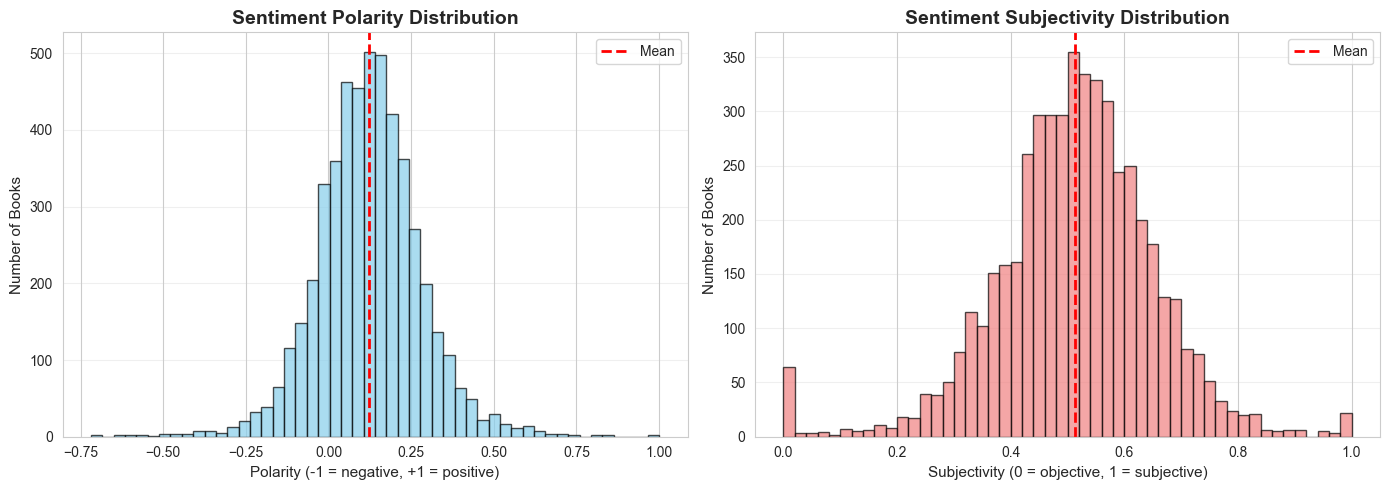

In [9]:
# Visualize sentiment distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Polarity distribution
axes[0].hist(df['sentiment_polarity'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['sentiment_polarity'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].set_title('Sentiment Polarity Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Polarity (-1 = negative, +1 = positive)', fontsize=11)
axes[0].set_ylabel('Number of Books', fontsize=11)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Subjectivity distribution
axes[1].hist(df['sentiment_subjectivity'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].axvline(df['sentiment_subjectivity'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1].set_title('Sentiment Subjectivity Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Subjectivity (0 = objective, 1 = subjective)', fontsize=11)
axes[1].set_ylabel('Number of Books', fontsize=11)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Generate Description Embeddings
Traditional features miss deeper semantic meaning in the descriptions. Luckily, `SentenceTransformer` embeddings capture narrative tone, topic similariy and contextual meaning. These vectors enable strong similarity modeling between books.

In this notebook, use a pre-trained sentence transformer model to create dense vector representations of book descriptions. These embeddings capture semantic meaning and will be used for finding similar books.

In [10]:
from sentence_transformers import SentenceTransformer

# Load pre-trained model
print("Loading sentence transformer model...")
print("Model: all-MiniLM-L6-v2 (fast, good quality, 384 dimensions)")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded successfully!")

Loading sentence transformer model...
Model: all-MiniLM-L6-v2 (fast, good quality, 384 dimensions)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!


In [11]:
# Generate embeddings for all descriptions
print("Generating embeddings for all book descriptions...")
print("This will take a few minutes for ~5000 books.\n")

descriptions = df['description_cleaned'].tolist()
embeddings = model.encode(
    descriptions,
    show_progress_bar=True,
    batch_size=32,
    convert_to_numpy=True
)

print(f"\nEmbeddings generated!")
print(f"Shape: {embeddings.shape}")
print(f"Each book is represented as a {embeddings.shape[1]}-dimensional vector")

Generating embeddings for all book descriptions...
This will take a few minutes for ~5000 books.



Batches:   0%|          | 0/157 [00:00<?, ?it/s]


Embeddings generated!
Shape: (5006, 384)
Each book is represented as a 384-dimensional vector


## Save Embeddings 
Embeddings are now saved separately to avoid recomputation, speed up experimentation, and allow reuse across multiple notebooks

In [12]:
import os

# Ensure output directory exists
os.makedirs('../data/processed', exist_ok=True)

# Save embeddings as numpy array
embeddings_path = '../data/processed/description_embeddings.npy'
np.save(embeddings_path, embeddings)

print(f"✓ Embeddings saved to: {embeddings_path}")
print(f"  Size: {embeddings.nbytes / 1024 / 1024:.2f} MB")

# Add embedding index to dataframe (for reference)
df['embedding_idx'] = df.index
print("✓ Added embedding_idx column to dataframe")

✓ Embeddings saved to: ../data/processed/description_embeddings.npy
  Size: 7.33 MB
✓ Added embedding_idx column to dataframe


## Create combined feature matrix
Here, we combine mood indicators, genre indicators, sentiment scores, and embeddings into a unified feature representatio suitable for modeling.

In [13]:
# Define all feature columns
feature_columns = (
    mood_cols +  # Binary mood features
    genre_cols +  # Binary genre features
    ['sentiment_polarity', 'sentiment_subjectivity'] +  # Sentiment features
    ['description_word_count', 'num_tags', 'average_rating']  # Metadata features
)

print(f"Total explicit features: {len(feature_columns)}")
print(f"\nFeature categories:")
print(f"  Mood features: {len(mood_cols)}")
print(f"  Genre features: {len(genre_cols)}")
print(f"  Sentiment features: 2")
print(f"  Metadata features: 3")
print(f"  Description embeddings: 384 (stored separately)")

# Extract feature matrix
X_features = df[feature_columns].values

print(f"\nFeature matrix shape: {X_features.shape}")
print(f"(rows = books, columns = features)")

Total explicit features: 26

Feature categories:
  Mood features: 6
  Genre features: 15
  Sentiment features: 2
  Metadata features: 3
  Description embeddings: 384 (stored separately)

Feature matrix shape: (5006, 26)
(rows = books, columns = features)


## Save feature-engineered dataset  
The completed dataset is saved for downstream notebooks.

In [14]:
# Save complete dataframe with all features
output_path = '../data/processed/books_with_features.csv'
df.to_csv(output_path, index=False)

print("=" * 60)
print("FEATURE ENGINEERING COMPLETE!")
print("=" * 60)
print(f"\n Dataset saved: {output_path}")
print(f" Embeddings saved: {embeddings_path}")
print(f"\nDataset summary:")
print(f"  Books: {len(df)}")
print(f"  Explicit features: {len(feature_columns)}")
print(f"  Embedding dimensions: {embeddings.shape[1]}")
print(f"\nReady for recommendation system development!")

FEATURE ENGINEERING COMPLETE!

 Dataset saved: ../data/processed/books_with_features.csv
 Embeddings saved: ../data/processed/description_embeddings.npy

Dataset summary:
  Books: 5006
  Explicit features: 26
  Embedding dimensions: 384

Ready for recommendation system development!


## Validation-Feature correlations
Highly correlated features may introduce redundancy. We inspect correlations to identify overlap between signals, reduce dimensionality if needed, and improve model stability. 

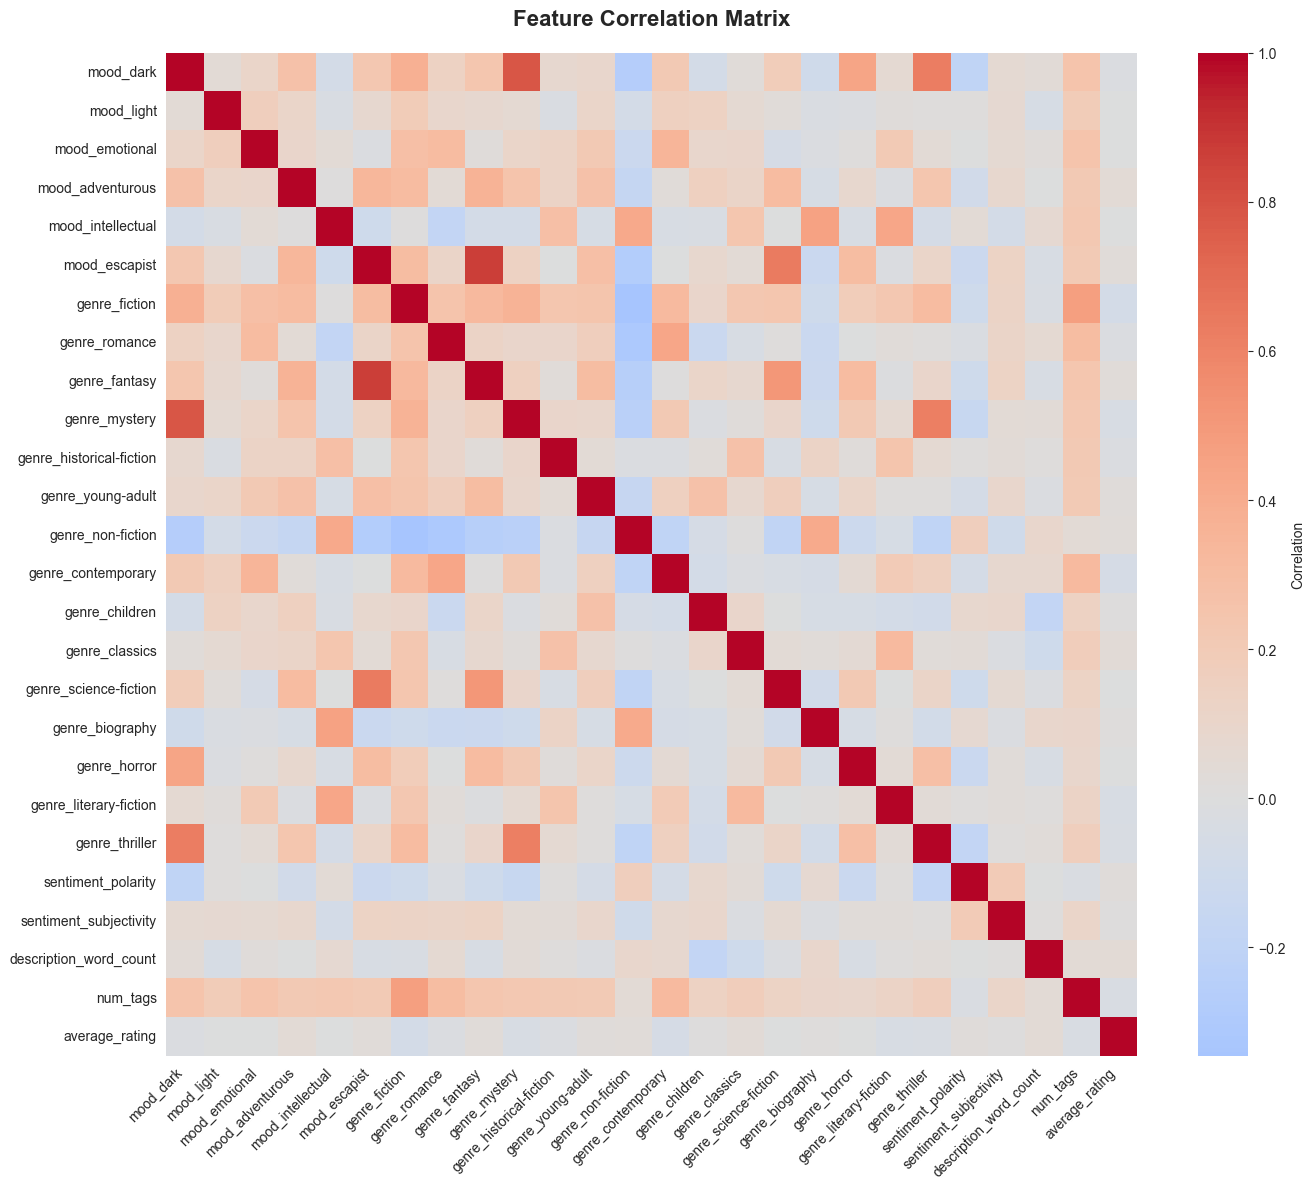

In [15]:
# Calculate correlation matrix for explicit features
feature_df = df[feature_columns]
corr_matrix = feature_df.corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
# Identify highly correlated feature pairs (potential redundancy)
high_corr_threshold = 0.7
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > high_corr_threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print(f"Found {len(high_corr_pairs)} highly correlated feature pairs (|r| > {high_corr_threshold}):\n")
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {feat1:30} <-> {feat2:30} : {corr:6.3f}")
    print("\nNote: High correlation might indicate redundant features.")
else:
    print(f"✓ No highly correlated features found (threshold: |r| > {high_corr_threshold})")
    print("  Features are relatively independent.")

Found 2 highly correlated feature pairs (|r| > 0.7):

  mood_escapist                  <-> genre_fantasy                  :  0.869
  mood_dark                      <-> genre_mystery                  :  0.782

Note: High correlation might indicate redundant features.


## Summary
In this notebook we:
- explored tag distributions
- created mood-based features
- encoded major genres
- extracted sentiment signals
- generated semantic embeddings
- assembled a modeling-ready feature matrix
- validated feature relationships

The dataset is now ready for machine learning tasks. 